In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gudhi
import networkx as nx
from tqdm import tqdm

from gudhi.representations import DiagramSelector
from gudhi.cover_complex import MapperComplex

from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances


# Random shapes

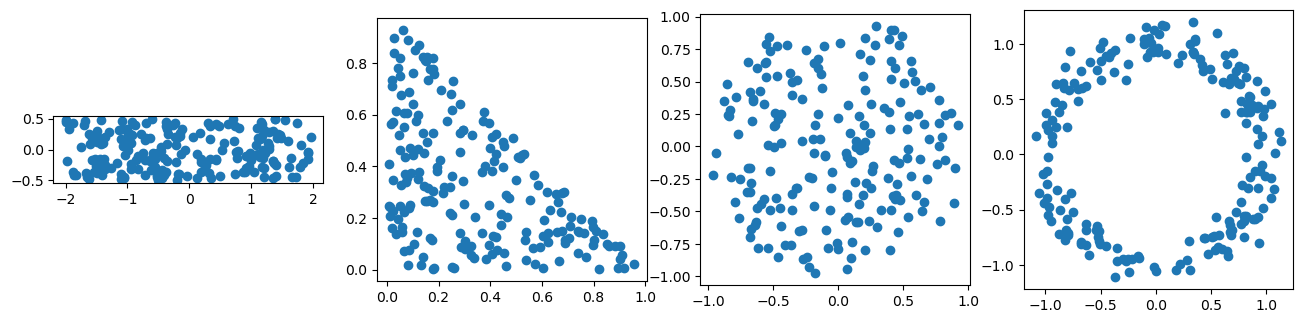

In [2]:
n = 200

def random_circle(n):
    X = np.random.normal(size=(n, 2))
    X = X / np.linalg.norm(X, axis=1).reshape(-1, 1)
    X = X + np.random.normal(size=(n, 2), scale = 0.1 )
    return X

def random_rectangle(n, width=2, height=1):
    X = np.zeros((n, 2))
    X[:, 0] = np.random.uniform(low=-width/2, high=width/2, size=n)   
    X[:, 1] = np.random.uniform(low=-height/2, high=height/2, size=n) 
    return X

def random_triangle(n):
    u = np.random.rand(n, 1)
    v = np.random.rand(n, 1)
    mask = (u + v > 1)
    u[mask] = 1 - u[mask]
    v[mask] = 1 - v[mask]
    X = np.hstack((u, v))
    return X

def random_disc(n, radius=1.0):
    r = radius * np.sqrt(np.random.rand(n))  
    theta = 2 * np.pi * np.random.rand(n)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    X = np.column_stack((x, y))
    return X

A = random_rectangle(n, 4,1)
B = random_triangle(n)
C = random_disc(n)
D = random_circle(n)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
ax1.scatter(A[:,0], A[:,1])
ax1.set_aspect('equal', adjustable='box')
ax2.scatter(B[:,0], B[:,1])
ax2.set_aspect('equal', adjustable='box')
ax3.scatter(C[:,0], C[:,1])
ax3.set_aspect('equal', adjustable='box')
ax4.scatter(D[:,0], D[:,1])
ax4.set_aspect('equal', adjustable='box')
plt.show()


# Clustering with Bottleneck distance

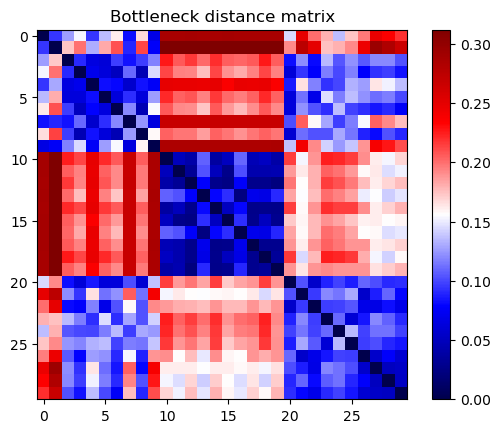

In [3]:
n = 50
shapes = []
DS = DiagramSelector(use = True, point_type = 'finite')

for _ in range(10):
    shapes.append(random_rectangle(n, 4,1))

for _ in range(10):
    shapes.append(random_triangle(n))

for _ in range(10):
    shapes.append(random_disc(n))
def data_to_persistence(DATA):
    rips_complex = gudhi.RipsComplex(points=DATA, max_edge_length=4.0)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)
    diag = simplex_tree.persistence(homology_coeff_field=2, min_persistence=0)
    return diag

def diagram_without_dim(diag):
    diag_ret = []
    for d in diag:
        diag_ret.append(d[1])
    return np.asarray(diag_ret)

def bottleneck_distance(diag1, diag2):
    diag1_bis = diagram_without_dim(diag1)
    diag2_bis = diagram_without_dim(diag2)
    diag1_finite = DS(diag1_bis)
    diag2_finite = DS(diag2_bis)
    return gudhi.hera.bottleneck_distance(diag1_finite, diag2_finite, delta= 0.01)

# test 
L = len(shapes)
bottleneck_matrix = np.zeros((L, L))
for i in range(L):
    diag1 = data_to_persistence(shapes[i])
    for j in range(L):
        diag2 = data_to_persistence(shapes[j])
        bottleneck_matrix[i, j] = bottleneck_distance(diag1, diag2)
        
plt.imshow(bottleneck_matrix, cmap='seismic')
plt.colorbar()
plt.title('Bottleneck distance matrix')
plt.show()

c:\Users\leoqu\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:601: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(
c:\Users\leoqu\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


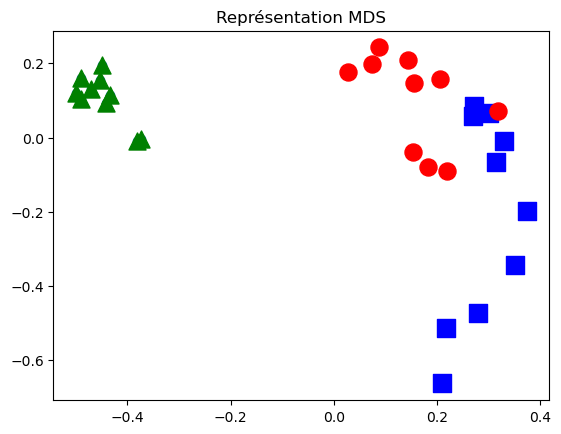

In [4]:

mds = MDS(n_components=2, random_state=0)
Y = mds.fit_transform(bottleneck_matrix)

plt.scatter(Y[:,0], Y[:,1])

for i in range(L):
    if i < 10:
        plt.scatter(Y[i,0], Y[i,1], color='blue', s = 150, marker='s')
    elif i < 20:
        plt.scatter(Y[i,0], Y[i,1], color='green',  s = 150, marker='^')
    else:   
        plt.scatter(Y[i,0], Y[i,1], color='red', s = 150, marker='o')

plt.title("Représentation MDS")

plt.show()

# Non-robustess test

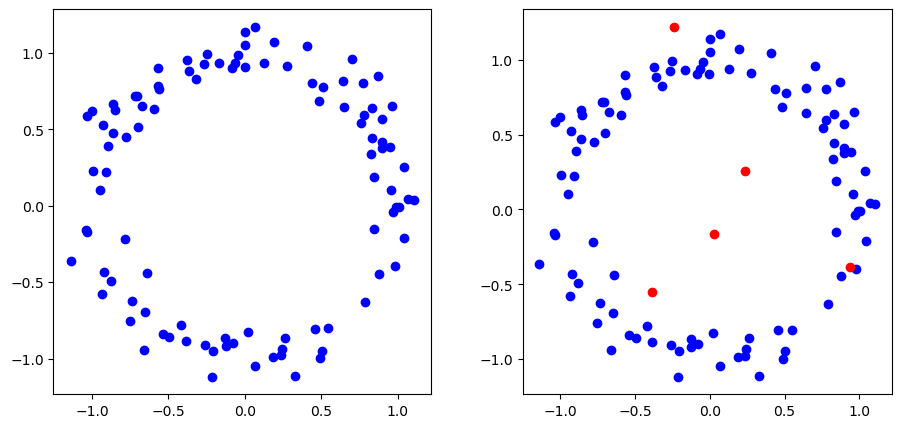

c:\Users\leoqu\anaconda3\Lib\site-packages\gudhi\persistence_graphical_tools.py:107: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


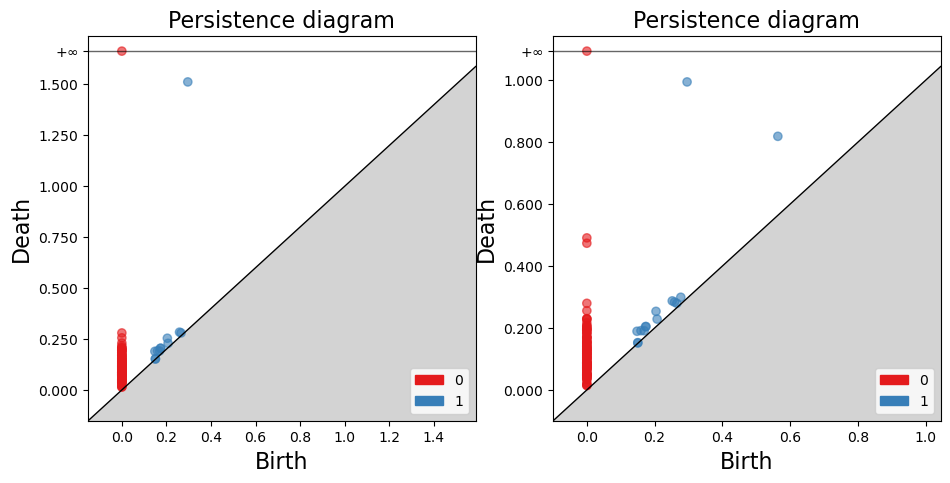

0.5172570542365227


In [5]:
n = 100
m = 5 # << n

DATA = np.array(random_circle(n))
noise = random_rectangle(m, width=3, height=3)
DATA_modified = np.append(DATA, noise, axis=0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
ax1.scatter(DATA[:, 0], DATA[:, 1], color='blue')
ax1.set_aspect('equal')
ax2.scatter(DATA[:, 0], DATA[:, 1], color='blue')
ax2.scatter(noise[:, 0], noise[:, 1], color='red')
ax2.set_aspect('equal')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
diag = data_to_persistence(DATA)
diag_modified = data_to_persistence(DATA_modified)
gudhi.plot_persistence_diagram(diag, axes=ax1)
gudhi.plot_persistence_diagram(diag_modified, axes=ax2)
plt.show()
print(bottleneck_distance(diag, diag_modified))

# Non-stability of the bottleneck distance for mappers
Mapper complex - test

In [15]:
def set_axes_equal(ax: plt.Axes):
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    origin = np.mean(limits, axis=1)
    radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
    x, y, z = origin
    ax.set_xlim3d([x - radius, x + radius])
    ax.set_ylim3d([y - radius, y + radius])
    ax.set_zlim3d([z - radius, z + radius])

def generate_torus(n=100, R=2, r=0.5):
    u = 2 * np.pi * np.random.rand(n)
    v = 2 * np.pi * np.random.rand(n)
    x = (R + r * np.cos(v)) * np.cos(u)
    y = (R + r * np.cos(v)) * np.sin(u)
    z = r * np.sin(v)
    return np.vstack((x, y, z)).T 
    

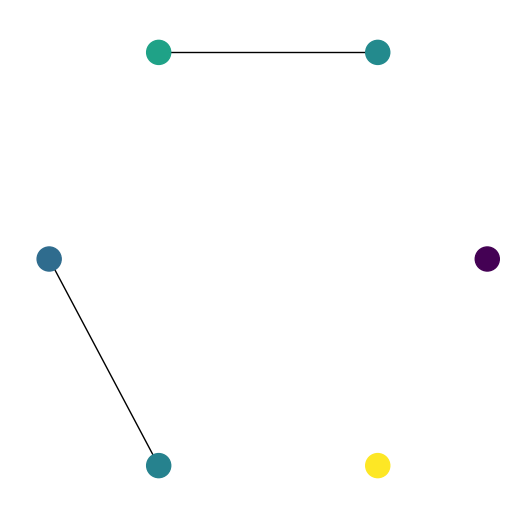

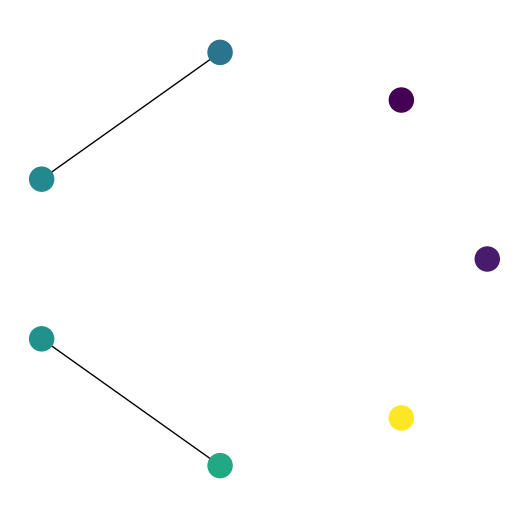

In [16]:

verbose = False

n = 50

X = np.array(random_circle(n))
height = X[:,1]

def cover_complex_with_filter(X, height, verbose=False):
    cover_complex = MapperComplex(
        input_type='point cloud', min_points_per_node=0,
        clustering=None, N=100, beta=0., C=10,
        filter_bnds=None, resolutions=None, gains=None,
        verbose=verbose)
    _ = cover_complex.fit(X, filters=height, colors=height)
    return cover_complex


cover_complex = MapperComplex(
    input_type='point cloud', min_points_per_node=0,
    clustering=None, N=100, beta=0., C=10,
    filter_bnds=None, resolutions=None, gains=None,
    verbose=verbose)
fig = plt.figure(figsize=(5, 5))
_ = cover_complex.fit(X, filters=height, colors=height)
G = cover_complex.get_networkx()
nx.draw(G, pos=nx.kamada_kawai_layout(G), node_color=[cover_complex.node_info_[v]["colors"][0] for v in G.nodes()])

delta = 0.5
height_modified = height - delta

cover_complex_modified = MapperComplex(
    input_type='point cloud', min_points_per_node=0,
    clustering=None, N=100, beta=0., C=10,
    filter_bnds=None, resolutions=None, gains=None,
    verbose=verbose)
fig = plt.figure(figsize=(5, 5))
_ = cover_complex_modified.fit(X, filters=height_modified, colors=height_modified)
G_modified = cover_complex_modified.get_networkx()
nx.draw(G_modified, pos=nx.kamada_kawai_layout(G_modified), node_color=[cover_complex_modified.node_info_[v]["colors"][0] for v in G_modified.nodes()])

Topological features, functions from https://github.com/GUDHI/TDA-tutorial

In [17]:
from scipy.sparse.csgraph    import dijkstra, shortest_path, connected_components
from scipy.stats             import ks_2samp

def find(i, parents):
    if parents[i] == i:
        return i
    else:
        return find(parents[i], parents)

def union(i, j, parents, f):
    if f[i] <= f[j]:
        parents[j] = i
    else:
        parents[i] = j
        
def compute_topological_features(M, threshold=0.):
    """
    Compute the topological features (connected components, up/down branches, loops) of the 1-skeleton of the cover complex. Connected components and loops are computed with scipy functions, and branches are detected with Union-Find and 0-dimensional persistence of the 1-skeleton.
    Parameters:
        threshold (float): any topological feature whose size is less than this parameter (relative to the first color function) will be discarded.
    Returns:
        dgm (list of (dim,(a,b)) tuples): list of feature characteristics. dim is the topological dimension of the feature (0 for CCs and branches, 1 for loops), a,b are the min and max of the first color function along the feature.
        bnds (list of lists): list of feature points. Each element of this list is the list of point IDs forming the corresponding feature. 
    """
    st = M.simplex_tree_
    num_nodes = st.num_vertices()
    function, namefunc, invnamefunc = {}, {}, {}
    nodeID = 0
    for (s,_) in st.get_skeleton(0):
        namefunc[s[0]] = nodeID
        invnamefunc[nodeID] = s[0]
        function[s[0]] = M.node_info_[s[0]]["colors"][0]
        nodeID += 1
    dgm, bnd = [], []

    # connected_components
    A = np.zeros([num_nodes, num_nodes])
    for (splx,_) in st.get_skeleton(1):
        if len(splx) == 2:
            A[namefunc[splx[0]], namefunc[splx[1]]] = 1
            A[namefunc[splx[1]], namefunc[splx[0]]] = 1
    _, ccs = connected_components(A, directed=False)
    for ccID in np.unique(ccs):
        pts = np.argwhere(ccs == ccID).flatten()
        vals = [function[invnamefunc[p]] for p in pts]
        if np.abs(min(vals) - max(vals)) >= threshold:
            dgm.append((0, (min(vals), max(vals))))
            bnd.append([invnamefunc[p] for p in pts])

    # loops
    G = M.get_networkx()
    try:
        from networkx import cycle_basis
        bndall = cycle_basis(G)
        for pts in bndall:
            vals = [function[p] for p in pts]
            if np.abs(min(vals) - max(vals)) >= threshold:	
                dgm.append((1,(min(vals), max(vals))))
                bnd.append(pts)
    except ImportError:
        print("Networkx not found, loops not computed")
        
    # branches
    for topo_type in ["downbranch", "upbranch"]:

        lfunction = []
        for i in range(num_nodes):
            lfunction.append(function[invnamefunc[i]])

        # upranch is downbranch of opposite function
        if topo_type == "upbranch":
            lfunction = [-f for f in lfunction]

        # sort vertices according to function values and compute inverse function 
        sorted_idxs = np.argsort(np.array(lfunction))
        inv_sorted_idxs = np.zeros(num_nodes)
        for i in range(num_nodes):
            inv_sorted_idxs[sorted_idxs[i]] = i

        # go through all vertices in ascending function order
        persistence_diag, persistence_set, parents, visited = {}, {}, -np.ones(num_nodes, dtype=np.int32), {}
        for i in range(num_nodes):

            current_pt = sorted_idxs[i]
            neighbors = np.ravel(np.argwhere(A[current_pt,:] == 1))
            lower_neighbors = [n for n in neighbors if inv_sorted_idxs[n] <= i] if len(neighbors) > 0 else []

            # no lower neighbors: current point is a local minimum
            if lower_neighbors == []:
                parents[current_pt] = current_pt

            # some lower neighbors exist
            else:

                # find parent pg of lower neighbors with lowest function value
                neigh_parents = [find(n, parents) for n in lower_neighbors]
                pg = neigh_parents[np.argmin([lfunction[n] for n in neigh_parents])]

                # set parent of current point to pg
                parents[current_pt] = pg

                # for each lower neighbor, we will create a persistence diagram point and corresponding set of nodes
                for neighbor in lower_neighbors:

                    # get parent pn
                    pn = find(neighbor, parents)
                    val = lfunction[pn]
                    persistence_set[pn] = []

                    # we will create persistence set only if parent pn is not local minimum pg
                    if pn != pg:
                        # go through all strictly lower nodes with parent pn
                        for v in sorted_idxs[:i]:
                            if find(v, parents) == pn:
                                # if it is already part of another persistence set, continue
                                try:
                                    visited[v]
                                # else, mark visited and include it in current persistence set
                                except KeyError:
                                    visited[v] = True
                                    persistence_set[pn].append(v)

                        # add current point to persistence set
                        persistence_set[pn].append(current_pt)

                        # do union and create persistence point corresponding to persistence set if persistence is sufficiently large
                        if np.abs(lfunction[pn]-lfunction[current_pt]) >= threshold:
                            persistence_diag[pn] = current_pt
                            union(pg, pn, parents, lfunction)

        for key, val in iter(persistence_diag.items()):
            if topo_type == "downbranch":
                dgm.append((0, (lfunction[key],  lfunction[val])))
            elif topo_type == "upbranch":
                dgm.append((0, (-lfunction[val], -lfunction[key])))
            bnd.append([invnamefunc[v] for v in persistence_set[key]])

    bnd = [list(b) for b in bnd]
    M.persistence_diagram, M.persistence_sets = dgm, bnd 
    return dgm, bnd

def bootstrap_topological_features(M, N):
    """
    Use bootstrap to empirically assess stability of the features. This function computes a distribution of bottleneck distances, that can used afterwards to run tests on each topological feature.
    Parameters:
        N (int): number of bootstrap iterations.
    """

    dgm = M.persistence_diagram
    num_pts, distribution = len(M.data), []
    for bootstrap_id in tqdm(range(N)):

        # Randomly select points
        idxs = np.random.choice(num_pts, size=num_pts, replace=True)
        Xboot = M.data[idxs,:] if M.input_type == "point cloud" else M.data[idxs,:][:,idxs]
        f_boot, c_boot = M.filters[idxs,:], M.colors[idxs,:]
        Mboot = M.__class__(filter_bnds=M.filter_bnds, resolutions=M.resolutions, gains=M.gains, 
                            input_type=M.input_type, clustering=M.clustering).fit(Xboot, filters=f_boot, colors=c_boot)

        # Compute the corresponding persistence diagrams
        dgm_boot, _ = compute_topological_features(Mboot)

        # Compute the bottleneck distance
        npts, npts_boot = len(dgm), len(dgm_boot)
        D1 = np.array([[dgm[pt][1][0], dgm[pt][1][1]] for pt in range(npts)]) 
        D2 = np.array([[dgm_boot[pt][1][0], dgm_boot[pt][1][1]] for pt in range(npts_boot)])
        bottle = bottleneck_distance(D1, D2)
        distribution.append(bottle)
        M.distribution = np.sort(distribution)

def get_distance_from_confidence_level(M, alpha=.95, complex_type='mapper'):
    """
    Compute the bottleneck distance threshold corresponding to a specific confidence level.
    Parameters:
        alpha (float): confidence level.
    Returns:
        distance value (float); each feature whose size is above this distance is sure at confidence level alpha.
    """
    return M.distribution[int(alpha*len(M.distribution))]

def get_confidence_level_from_distance(M, distance):
    """
    Compute the confidence level of a specific bottleneck distance threshold.
    Parameters:
        distance (float): bottleneck distance threshold.
    Returns:
        confidence level (float); each feature whose size is above the distance threshold is sure at this confidence level.
    """
    return len(np.argwhere(M.distribution <= distance))/len(M.distribution)

def get_pvalue(M):
    """
    Compute the p-value, i.e. the opposite of the confidence level of the largest bottleneck distance preserving the topological features.
    Returns:
        p-value (float)
    """
    distancemin = min([np.abs(pt[1][0]-pt[1][1]) for pt in M.persistence_diagram])
    return 1.-M.compute_confidence_from_distance(distancemin)

def compute_differential_coordinates(M, nodes=None, features=None, sparse=False):
    """
    Compute the coordinates that best explain a set of nodes VS the rest of the nodes (in the 1-skeleton of the cover complex) with a Kolmogorov-Smirnov test. Only works if input_type is "point cloud".
    Parameters:
        nodes (list of integers): list of nodes to try. For instance, one can take the list of nodes obtained after calling "compute_topological_features"
        features (list of integers): the coordinates to try. All coordinates are tested if None.
        sparse (bool): set to True if your data is sparse and there will be speedup, otherwise use False.
    Returns:
        features (list of integers): the list of coordinates, ranked from smallest to largest p-values.
        p-values (list of float): the corresponding p-values. 
    """
    if M.input_type == "distance matrix":
        print("Need coordinates for running differential coordinates!")
        raise

    node_info = M.node_info_
    X = M.data
    nodes = [s[0] for s,_ in self.simplex_tree_.get_skeleton(0)] if nodes is None else nodes

    if features is None:
        features = np.arange(X.shape[1])

    list_idxs1 = list(np.unique(np.concatenate([node_info[node_name]["indices"] for node_name in nodes])))
    list_idxs2 = list(set(np.arange(X.shape[0]))-set(list_idxs1))
    pvals = []
    for f in features:
        if sparse:
            Xsp = csr_matrix(X)
            group1 = np.squeeze(np.array(Xsp[list_idxs1,f].todense()))
            group2 = np.squeeze(np.array(Xsp[list_idxs2,f].todense()))
        else:
            group1, group2 = X[list_idxs1,f], X[list_idxs2,f]
        _,pval = ks_2samp(group1, group2)
        pvals.append(pval)
    pvals = np.array(pvals)
    F, P = features[np.argsort(pvals)], np.sort(pvals) 
    return F, P

In [ ]:
dgm, bnd = compute_topological_features(cover_complex, threshold=0.)
dgm_modified, bnd_modified = compute_topological_features(cover_complex_modified, threshold=0.)

dgm1_points = np.array([bd for dim, bd in dgm])
dgm2_points = np.array([bd for dim, bd in dgm_modified])

dist = gudhi.bottleneck_distance(dgm1_points, dgm2_points, e=0.001) 